# Electrical resistivity from $\alpha^2F_{\rm tr}$: the band-resolved Boltzmann equation

The electron-phonon spectral function that gives $T_c$ also gives the
*resistivity*, and the second is the more searching test of the two. $T_c$ is
exponentially sensitive to $\mu^*$, so a factor-of-two error in the vertex can
hide inside a plausible-looking $T_c$; $\rho(T)$ has no such adjustable
parameter, and experiment is unambiguous. This notebook implements that route
and checks it against measured resistivities.

The method is Allen's lowest-order variational approximation (LOVA) to the
linearised Boltzmann equation — P. B. Allen, *Phys. Rev. B* **17**, 3725 (1978);
Grimvall Ch. 7; Ziman Ch. 7 for the variational principle — generalised here to
several Fermi-surface sheets.

## The equations

Restrict the trial deviation function to one amplitude per sheet, proportional
to the velocity,

$$\phi_{\mathbf k} = \Phi_i\, v_a(\mathbf k)\qquad
  \text{for } \mathbf k \text{ on sheet } i,\ \text{field along } a,$$

substitute into the variational resistivity functional and minimise. The result
is a linear system in sheet space:

$$\sum_j M^a_{ij}(T)\, \Phi_j = D^a_i,\qquad
  \sigma_a = \frac{n_{\rm spin} e^2}{\Omega}\sum_i D^a_i \Phi_i$$

$$M^a_{ij} = \delta_{ij}\sum_l A^a_{il} - C^a_{ij},\qquad
  K(\omega,T) = \frac{4\pi k_BT}{\omega}\left[\frac{y}{\sinh y}\right]^2,\quad
  y = \frac{\omega}{2k_BT}$$

with $A$ built from the spectral function weighted by $v_a(\mathbf k)^2$ and $C$
from the one weighted by $v_a(\mathbf k)\,v_a(\mathbf k+\mathbf q)$, and
$D^a_i = N_i\langle v_a^2\rangle_i$ the per-sheet Drude weight.

## Why two spectral functions and not one $\alpha^2F_{\rm tr}$

For a single sheet, Allen's transport spectral function is exactly

$$\alpha^2F_{\rm tr}(\omega) = \frac{F^{\rm out}(\omega)-F^{\rm in}(\omega)}{D},$$

the difference being all that survives because out- and in-scattering enter the
single-band collision term with opposite sign. **In band space that
cancellation is not local**: the out-weight sits on the diagonal *summed over
all final sheets*, the in-weight off-diagonal. A pre-subtracted
$\alpha^2F_{\rm tr}$ per sheet pair has thrown that structure away, and with it
the physics — interband scattering that preserves the current direction
($v_a(\mathbf k)v_a(\mathbf k+\mathbf q) > 0$) relaxes the current *less* than
its out-scattering rate alone implies. So `elph.alpha2f_transport_matrix`
returns $F^{\rm out}$ and $F^{\rm in}$ separately, un-normalised by any DOS.

Minimising over $n_{\rm sheets}$ parameters is *exact within that trial space*,
so the variational step costs nothing; the approximation is entirely the ansatz.
A corollary used below as a check: a larger trial space can only lower $\rho$,
so the band-resolved $\sigma$ never falls below the single-$\Phi$ (isotropic)
one.

## Two conventions that do not cancel

**The spin factor.** Electron-phonon scattering is spin-diagonal, so $M$ and
$\tau_{\rm tr}$ are per-spin quantities carrying no factor, while the current
sums over both channels. Unlike in $\lambda$, the factor does *not* cancel:
`num_elec_per_state=2`. Omitting it halves $\sigma$.

**Which $\alpha^2F_{\rm tr}$.** `elph.alpha2f(velocities=...)` applies the
*dimensionless* $1 - (\mathbf v_{\mathbf k}\!\cdot\!\mathbf v_{\mathbf
k+\mathbf q})/|\mathbf v_{\mathbf k}|^2$ and divides by $N(E_F)$ — EPW's
transport-$\lambda$ convention, in which every Fermi-surface point carries equal
weight. Allen's $\alpha^2F_{\rm tr}$ instead weights each $\mathbf k$ by
$v_a(\mathbf k)^2$, which is what the variational algebra produces, and only
that one closes the Boltzmann equation. The two agree only where $|v|$ is
constant over the Fermi surface. Neither is wrong; they are different averages.

## What this route does not give

No energy resolution of the deviation function — the degenerate limit is taken,
so this yields $\sigma(T)$ and nothing else. Seebeck, the Lorenz number and any
Wiedemann-Franz violation live precisely in the $\partial/\partial\varepsilon$
structure integrated out here (`analysis.boltzmann` has those, under a constant
relaxation time instead). Phonons are in equilibrium: no drag. Anisotropy
*within* a sheet is gone, which for transport is a sharper loss than for $T_c$
because $\sigma$ weights $v^2$. Only diagonal $\sigma_{aa}$.

In [1]:
import sys, pathlib, warnings, time
import numpy as np
import matplotlib.pyplot as plt
import torch

HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
warnings.simplefilter('ignore')

import waw
waw.set_num_threads(16)
from ase import Atoms
from ase.build import bulk
from ase.spacegroup import crystal
from waw.core.hamiltonian import HamiltonianR
from waw.analysis import elph
from waw.analysis.band_sheets import (band_character_weights, sheet_dos,
                                      sheet_drude_weight)
from waw.analysis.elph_boltzmann import (lova_conductivity, lump_sheets,
                                         lambda_tr, transport_kernel,
                                         spin_resolved_conductivity)
from waw.analysis.phonon import (interpolate_phonons,
                                 apply_acoustic_sum_rule)
from waw.analysis.wigner_transport import velocity_matrix
from waw.interfaces.ase.structure import (monkhorst_pack, irreducible_qpoints,
                                          real_lattice, recip_lattice)
from waw.interfaces.quantum_espresso.io import read_bands_eigenvalues
from waw.interfaces.quantum_espresso.phonon_io import read_force_constants
from waw.units import (CM1_TO_HARTREE, HARTREE_TO_EV, EV_TO_HARTREE,
                       K_B_HARTREE, BOHR_TO_ANG)

RUNS = REPO / 'workflows' / 'notebooks' / 'runs'

# Categorical slots 1-3 of the project palette, in fixed order (never cycled):
# blue = the calculation, orange = experiment / the second material, aqua = a
# third series. The ordered one-hue blue ramp is for series that differ only by
# a magnitude (temperature below).
C_CALC, C_EXP, C_THIRD = '#2a78d6', '#eb6834', '#1baf7a'
BLUE_RAMP = ['#86b6ef', '#2a78d6', '#104281']
plt.rcParams.update({'figure.dpi': 140, 'axes.grid': True,
                     'grid.alpha': 0.25, 'grid.linewidth': 0.6,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.axisbelow': True, 'font.size': 9})

SIGMA_E = elph.epw_degauss_to_sigma(0.05 * EV_TO_HARTREE)   # EPW's 0.05 eV
print(f'electronic smearing sigma_e = {SIGMA_E*HARTREE_TO_EV*1e3:.2f} meV')

electronic smearing sigma_e = 35.36 meV


## 1. The temperature kernel, and the two limits that pin its normalisation

$K(\omega,T)$ looks doubly singular and is not: $[y/\sinh y]^2 \to 1$ as
$\omega\to0$ leaves $K \sim 4\pi k_BT/\omega$, and the spectral functions vanish
at least as fast as $\omega^2$ (as $\omega^4$ once the velocity weights are in),
so the integrand is finite. The exponential suppression for $\omega \gg k_BT$ is
what makes $\rho$ fall as $T^5$ rather than $T^3$.

Two analytic limits fix the whole normalisation, and both are checked
numerically here rather than asserted:

* **high $T$**: $1/\tau_{\rm tr} \to 2\pi\lambda_{\rm tr}k_BT$ — the standard
  slope-to-$\lambda_{\rm tr}$ relation, so $\rho$ is linear through the origin;
* **low $T$**: with a Debye $\alpha^2F_{\rm tr}\sim\omega^4$, Bloch-Grüneisen
  $\rho \sim T^5$. This is the exponent a self-energy relaxation time (SERTA,
  no vertex factor) gets wrong as $T^3$, so it is the sharpest check that the
  transport weight is actually being used.

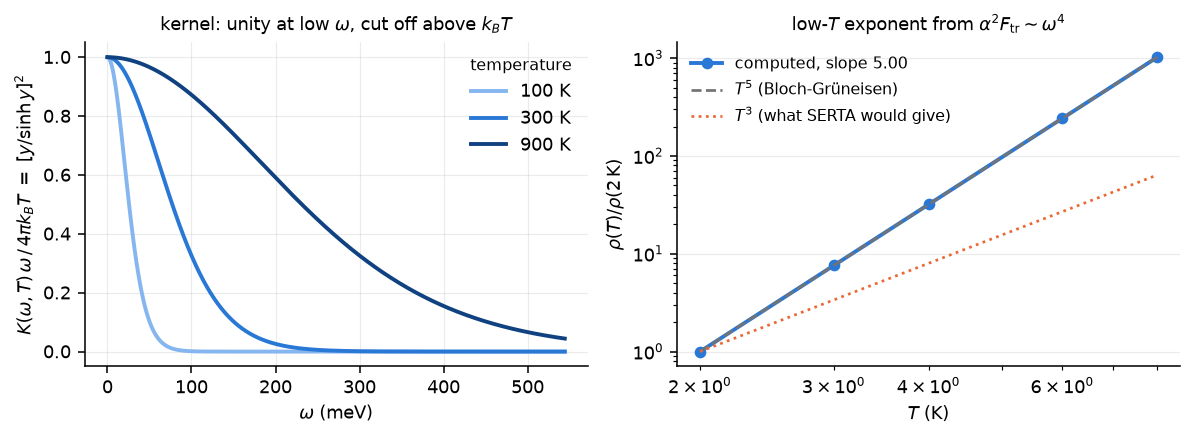

high-T check at 3000 K (kT >> omega_ph):
  lambda_tr recovered      = 1.3001   (input 1.3)
  tau_tr from the solver   = 12.9328 a.u.
  2 pi lambda_tr kT  =>      12.8852 a.u.   ratio 1.0037
low-T fitted exponent      = 5.000   (Bloch-Gruneisen 5)


In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.6, 3.2))

# --- kernel shape, ordered by temperature => one-hue ramp, light to dark
w = np.linspace(1e-8, 0.02, 900)
for (T, c) in zip((100.0, 300.0, 900.0), BLUE_RAMP):
    kT = T * K_B_HARTREE
    ax1.plot(w * HARTREE_TO_EV * 1e3, transport_kernel(w, kT) * w / (4 * np.pi * kT),
             color=c, lw=2, label=f'{T:.0f} K')
ax1.set_xlabel(r'$\omega$ (meV)')
ax1.set_ylabel(r'$K(\omega,T)\,\omega\,/\,4\pi k_BT\ =\ [y/\sinh y]^2$')
ax1.set_title('kernel: unity at low $\\omega$, cut off above $k_BT$', fontsize=9)
ax1.legend(frameon=False, title='temperature', title_fontsize=8)

# --- the T^5 law, from a Debye w^4 spectral function
wd = 0.001                                    # Debye energy, Hartree (~316 K)
wg = np.linspace(0.0, wd, 3000)
f_out = np.repeat(((wg / wd) ** 4 * 1e-3)[None, None, None, :], 3, axis=0)
from waw.analysis.elph import TransportSpectralMatrix
debye = TransportSpectralMatrix(omega=wg, f_out=f_out, f_in=np.zeros_like(f_out),
                                drude=np.ones((3, 1)), dos=np.ones(1))
Tlow = np.array([2., 3., 4., 6., 8.])
rho_low = 1.0 / lova_conductivity(debye, Tlow, 100.0).sigma[:, 0]
slope = np.polyfit(np.log(Tlow), np.log(rho_low), 1)[0]
ax2.loglog(Tlow, rho_low / rho_low[0], 'o-', color=C_CALC, lw=2, ms=5,
           label=f'computed, slope {slope:.2f}')
ax2.loglog(Tlow, (Tlow / Tlow[0]) ** 5, '--', color='0.45', lw=1.4,
           label=r'$T^5$ (Bloch-Grüneisen)')
ax2.loglog(Tlow, (Tlow / Tlow[0]) ** 3, ':', color=C_EXP, lw=1.4,
           label=r'$T^3$ (what SERTA would give)')
ax2.set_xlabel('$T$ (K)'); ax2.set_ylabel(r'$\rho(T)/\rho(2\,$K$)$')
ax2.set_title('low-$T$ exponent from $\\alpha^2F_{\\rm tr}\\sim\\omega^4$', fontsize=9)
ax2.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

# high-T limit, through the solver
wph = 0.002
wgrid = np.linspace(0.0, 0.004, 4001)
gau = np.exp(-0.5 * ((wgrid - wph) / 2e-5) ** 2) / (2e-5 * np.sqrt(2 * np.pi))
lam_in = 1.3
f_o = np.repeat((lam_in * 2.5 * (wph / 2) * gau)[None, None, None, :], 3, axis=0)
ein = TransportSpectralMatrix(omega=wgrid, f_out=f_o, f_in=np.zeros_like(f_o),
                              drude=np.full((3, 1), 2.5), dos=np.ones(1))
r_hi = lova_conductivity(ein, [3000.0], 100.0)
tau_num = r_hi.tau_transport()[0, 0]
tau_ana = 1.0 / (2 * np.pi * lambda_tr(ein) * 3000.0 * K_B_HARTREE)
print(f'high-T check at 3000 K (kT >> omega_ph):')
print(f'  lambda_tr recovered      = {lambda_tr(ein):.4f}   (input 1.3)')
print(f'  tau_tr from the solver   = {tau_num:.4f} a.u.')
print(f'  2 pi lambda_tr kT  =>      {tau_ana:.4f} a.u.   ratio {tau_num/tau_ana:.4f}')
print(f'low-T fitted exponent      = {slope:.3f}   (Bloch-Gruneisen 5)')

## 2. Aluminium — the single-sheet case, against a measured resistivity

Al reuses notebook 13's completed electron-phonon run: 4 MLWFs ($s$+$p$ on the
one atom), $g(R_e,R_q)$ on a $12^3$ electron / $6^3$ phonon mesh. One sheet, so
the band-resolved machinery must reduce *exactly* to Allen's textbook formula —
and it is a nearly-free-electron metal, which makes the Drude weight checkable
independently.

### Check the Drude weight before reading any resistivity

$\Omega_p^2 = 4\pi n_{\rm spin} D/\Omega$ is temperature- and
coupling-independent, is a *single* Fermi-surface integral (so it converges far
faster than $\lambda$), and $\sigma \propto \Omega_p^2$. That makes it the
cheapest possible test of whether the velocities and the mesh are sound, before
any of the el-ph machinery is involved. `LovaTransport.plasma_frequency()`
exists for exactly this.

One caution learned the hard way: the *free-electron* $\sqrt{4\pi n}$ is **not**
the right target. It assumes $m^*=m$ and all valence electrons, and is the
high-frequency plasmon (15.8 eV for Al), not the Fermi-surface Drude weight
(~12 eV). The meaningful benchmarks are the code's own dense-mesh limit and the
DFT band velocities, both used below.

In [3]:
A_AL = 4.0495
al = Atoms('Al', scaled_positions=[[0, 0, 0]],
           cell=A_AL * np.array([[-.5, 0, .5], [0, .5, .5], [-.5, .5, 0]]), pbc=True)
AL = RUNS / 'al_elph_alpha2f'
lat_al, rec_al = real_lattice(al), recip_lattice(al)
vol_al = abs(np.linalg.det(lat_al))
hr_al = waw.load_wannier_result(AL / 'al_wannier_result.npz').hr

n_fe = 3.0 / vol_al
op_fe = np.sqrt(4 * np.pi * n_fe)
print(f'Al: {vol_al:.2f} Bohr^3, free-electron sqrt(4 pi n) = '
      f'{op_fe*HARTREE_TO_EV:.2f} eV  (NOT the target -- see above)')
print('  mesh    E_F (eV)   N(eF)/spin   D_x (Ha Bohr^2)   Omega_p (eV)')
for m in (24, 32, 40, 48, 56):
    k = monkhorst_pack((m,) * 3)
    eig, U = elph.band_eigensystem(hr_al, k)
    ef = elph.fermi_level_from_electron_count(eig, 3.0, SIGMA_E)
    v = np.real(np.einsum('knna->kna', velocity_matrix(hr_al, k, rec_al)[1]))
    wch = band_character_weights(U, [[0, 1, 2, 3]])
    d = sheet_drude_weight(eig, v, ef, wch, SIGMA_E)[0, 0]
    op = np.sqrt(4 * np.pi * 2 * d / vol_al)
    print(f'  {m:3d}^3  {ef*HARTREE_TO_EV:8.4f}   {sheet_dos(eig, ef, wch, SIGMA_E)[0]:8.4f}   '
          f'{d:12.5f}      {op*HARTREE_TO_EV:8.3f}')

Al: 112.03 Bohr^3, free-electron sqrt(4 pi n) = 15.79 eV  (NOT the target -- see above)
  mesh    E_F (eV)   N(eF)/spin   D_x (Ha Bohr^2)   Omega_p (eV)


   24^3    7.8314     7.8230        1.06147        13.279


   32^3    7.8286     5.2053        0.80574        11.569


   40^3    7.8506     5.4917        0.86980        12.020


   48^3    7.8420     5.5673        0.86705        12.001


   56^3    7.8396     5.9087        0.90015        12.228


In [4]:
# Are the model's Fermi velocities right? Compare |dE/dk| near E_F against the
# QE bands on their own path -- the Drude weight is an average of exactly this.
txt = (AL / 'al.bands.in').read_text().splitlines()
i0 = next(j for j, l in enumerate(txt) if 'K_POINTS' in l)
nk_path = int(txt[i0 + 1].split()[0])
k_path = np.array([[float(x) for x in txt[i0 + 2 + j].split()[:3]] for j in range(nk_path)])
qe_bands = read_bands_eigenvalues(AL / 'al.bands.out', 12)[:, :hr_al.nw] * EV_TO_HARTREE
w_bands, _ = elph.band_eigensystem(hr_al, k_path)
EF_AL = elph.fermi_level_from_electron_count(
    elph.band_eigensystem(hr_al, monkhorst_pack((56,) * 3))[0], 3.0, SIGMA_E)

kc = k_path @ rec_al
dk = np.linalg.norm(np.diff(kc, axis=0), axis=1)
ok = dk > 1e-8
for label, arr in (('QE (DFT)', qe_bands), ('Wannier model', w_bands)):
    sl = np.abs(np.diff(arr, axis=0)[ok]) / dk[ok][:, None]
    near = np.abs(arr[:-1][ok] - EF_AL) < 0.05          # within ~1.4 eV of E_F
    print(f'  mean |dE/dk| within 1.4 eV of E_F, {label:14s}: {sl[near].mean():.4f} Ha*Bohr')
print('  => the velocities agree to ~5%, so Omega_p ~ 12 eV is the model\'s '
      'genuine\n     Drude weight, not an interpolation artefact.')

  mean |dE/dk| within 1.4 eV of E_F, QE (DFT)      : 0.2818 Ha*Bohr
  mean |dE/dk| within 1.4 eV of E_F, Wannier model : 0.2955 Ha*Bohr
  => the velocities agree to ~5%, so Omega_p ~ 12 eV is the model's genuine
     Drude weight, not an interpolation artefact.


In [5]:
# --- the transport ladder. Fixed sigma_e, irreducible q wedge, fine k.
zg = np.load(AL / 'al_gR.npz')
gal = (zg['g_R'], zg['R_e'], zg['degen_e'], zg['R_q'], zg['degen_q'])
fc_al = read_force_constants(AL / 'al.fc')
q_al, qw_al = irreducible_qpoints(al, (6, 6, 6))
ph_al = interpolate_phonons(fc_al, lat_al, np.zeros((1, 3)), q_al)
om_al, ev_al = CM1_TO_HARTREE * ph_al.freq_cm1, ph_al.eigvecs
og_al = np.linspace(1e-6, om_al.max() * 1.2, 300)
FST_AL = 12.0 * SIGMA_E + om_al.max()
T = np.array([50., 77., 100., 150., 200., 273.15, 300., 400., 500.])
RHO_EXP_AL = {77.: 0.245, 273.15: 2.42, 300.: 2.74}      # CRC / Landolt-Börnstein

print(f'{len(q_al)} irreducible q of 6^3; phonons to {om_al.max()*HARTREE_TO_EV*1e3:.1f} meV')
print('  mesh    t(s)   lam_tr    D_x    Omega_p(eV)   rho(300 K)   rho(77 K)')
al_rows, al_rho = [], None
for m in (24, 32, 40, 48, 56):
    t0 = time.time()
    k = monkhorst_pack((m,) * 3)
    eig, U = elph.band_eigensystem(hr_al, k)
    ef = elph.fermi_level_from_electron_count(eig, 3.0, SIGMA_E)
    v = np.real(np.einsum('knna->kna', velocity_matrix(hr_al, k, rec_al)[1]))
    sp = elph.alpha2f_transport_matrix(
        eig, U, *gal, k, q_al, None, om_al, ev_al,
        np.array([26.9815]), np.array([0]), fermi_energy=ef,
        orbital_groups=[[0, 1, 2, 3]], omega_grid=og_al, velocities=v,
        sigma_e=SIGMA_E, hr=hr_al, recip_lattice=rec_al, fsthick=FST_AL,
        q_weights=qw_al)
    r = lova_conductivity(sp, T, vol_al)
    rho = r.resistivity_microohm_cm[:, 0]
    al_rows.append((m, lambda_tr(sp), float(sp.drude[0].sum()),
                    r.plasma_frequency()[0] * HARTREE_TO_EV, rho[6], rho[1]))
    al_rho, al_sp = rho, sp
    print(f'  {m:3d}^3 {time.time()-t0:6.0f}   {al_rows[-1][1]:6.4f}  {al_rows[-1][2]:6.4f}   '
          f'{al_rows[-1][3]:8.3f}   {rho[6]:9.3f}   {rho[1]:9.4f}')

al_rows = np.array(al_rows)
conv = al_rows[1:]                       # 24^3 is not yet in the asymptotic regime
print(f'\nconverged (32^3 and finer): rho(300 K) = {conv[:,4].mean():.2f} '
      f'+- {conv[:,4].std():.2f} micro-Ohm cm   [experiment 2.74]')
print(f'                            lambda_tr = {conv[:,1].mean():.3f} '
      f'+- {conv[:,1].std():.3f}      [literature 0.35-0.40]')

16 irreducible q of 6^3; phonons to 44.7 meV
  mesh    t(s)   lam_tr    D_x    Omega_p(eV)   rho(300 K)   rho(77 K)


   24^3      4   0.7670  1.0615     13.279       4.890      0.6120


   32^3     10   0.3262  0.8057     11.569       2.716      0.3034


   40^3     19   0.3352  0.8698     12.020       2.600      0.3077


   48^3     32   0.3686  0.8671     12.001       2.844      0.3037


   56^3     50   0.3603  0.9001     12.228       2.709      0.3395

converged (32^3 and finer): rho(300 K) = 2.72 +- 0.09 micro-Ohm cm   [experiment 2.74]
                            lambda_tr = 0.348 +- 0.017      [literature 0.35-0.40]


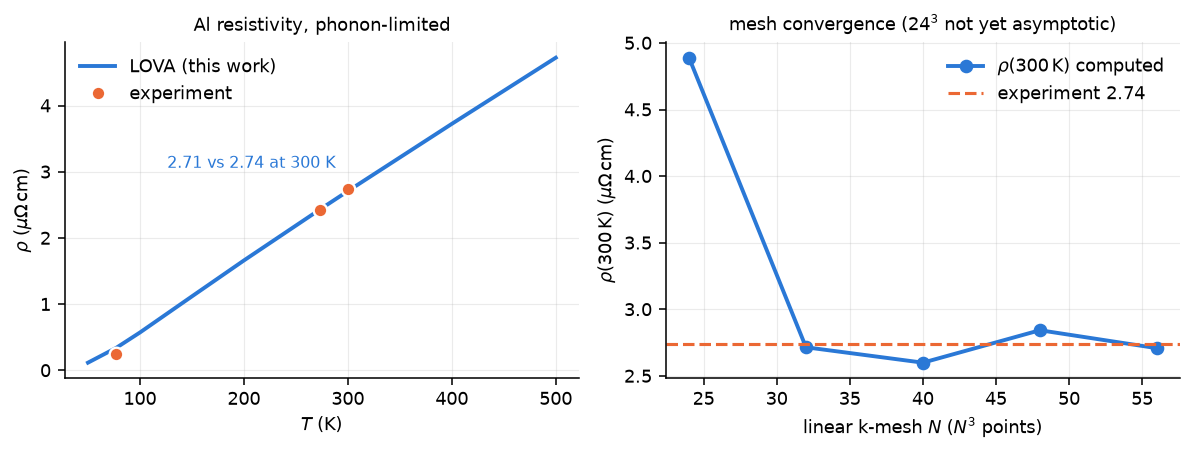

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.6, 3.3))

ax1.plot(T, al_rho, '-', color=C_CALC, lw=2, label='LOVA (this work)')
ax1.plot(list(RHO_EXP_AL), list(RHO_EXP_AL.values()), 'o', color=C_EXP, ms=7,
         mec='white', mew=1.2, label='experiment', zorder=3)
ax1.set_xlabel('$T$ (K)'); ax1.set_ylabel(r'$\rho$ ($\mu\Omega\,$cm)')
ax1.set_title('Al resistivity, phonon-limited', fontsize=9)
ax1.legend(frameon=False)
ax1.annotate(f'{al_rho[6]:.2f} vs 2.74 at 300 K', xy=(300, al_rho[6]),
             xytext=(-6, 12), textcoords='offset points', fontsize=8,
             color=C_CALC, ha='right')

ax2.plot(al_rows[:, 0], al_rows[:, 4], 'o-', color=C_CALC, lw=2, ms=6,
         label=r'$\rho(300\,$K$)$ computed')
ax2.axhline(2.74, color=C_EXP, lw=1.6, ls='--', label='experiment 2.74')
ax2.set_xlabel('linear k-mesh $N$ ($N^3$ points)')
ax2.set_ylabel(r'$\rho(300\,$K$)$ ($\mu\Omega\,$cm)')
ax2.set_title('mesh convergence ($24^3$ not yet asymptotic)', fontsize=9)
ax2.legend(frameon=False)
plt.tight_layout(); plt.show()

## 3. MgB$_2$ — where band resolution earns its keep

MgB$_2$ is the canonical two-sheet metal: quasi-2D $\sigma$ cylinders from the
in-plane B $sp^2$ bonds, and 3D $\pi$ tubes from B $p_z$. Notebook 16's
completed run supplies $g(R_e,R_q)$ and the 8 B-derived MLWFs; the sheets are
split by orbital character, $\sigma = \{s,p_x,p_y\}$ and $\pi = \{p_z\}$.

On Al, resolving the (single) sheet changed $\sigma$ by 1 part in $10^6$ — it
must, there being nothing to resolve. Here it should matter, and by how much is
the question this notebook exists to answer.

In [7]:
A_HEX, C_HEX = 3.086, 3.523
mgb2 = crystal(['Mg', 'B'], basis=[(0, 0, 0), (1/3, 2/3, 1/2)],
               spacegroup=191, cellpar=[A_HEX, A_HEX, C_HEX, 90, 90, 120])
MG = RUNS / 'mgb2_elph'
lat_m, rec_m = real_lattice(mgb2), recip_lattice(mgb2)
vol_m = abs(np.linalg.det(lat_m))
zh = np.load(MG / 'mgb2_hr_v2.npz')
hr_m = HamiltonianR(H_R=torch.from_numpy(zh['H_R']), R_vectors=zh['R'].astype(np.int64),
                    degen=zh['degen'].astype(np.int64), nw=int(zh['nw']))
zgm = np.load(MG / 'mgb2_gR_v2.npz')
gm = (zgm['g_R'], zgm['R_e'], zgm['degen_e'], zgm['R_q'], zgm['degen_q'])
EF_M = float(np.load(MG / 'night_v2' / 'iso_48x48x36.npz')['EF'])   # nb16's own E_F
SIG_ORB = [i for i in range(8) if i % 4 != 1]        # B s, px, py  (in-plane)
PI_ORB = [i for i in range(8) if i % 4 == 1]         # B pz
fc_m = read_force_constants(MG / 'mgb2.fc')
q_m, qw_m = irreducible_qpoints(mgb2, (6, 6, 4))
ph_m = interpolate_phonons(fc_m, lat_m, mgb2.get_scaled_positions(), q_m)
om_m, ev_m = CM1_TO_HARTREE * ph_m.freq_cm1, ph_m.eigvecs
og_m = np.linspace(1e-6, om_m.max() * 1.2, 300)
FST_M = 12.0 * SIGMA_E + om_m.max()
types_m = np.array([0 if s == 'Mg' else 1 for s in mgb2.get_chemical_symbols()])

print(f'MgB2: {vol_m:.2f} Bohr^3, E_F = {EF_M*HARTREE_TO_EV:.4f} eV, '
      f'{len(q_m)} irr q of 6x6x4, phonons to {om_m.max()*HARTREE_TO_EV*1e3:.1f} meV')
print('  mesh           t(s)  lam_tr  Omega_p,ab   rho_ab(300K)  band/lumped')
mg_rows = []
for m in [(28, 28, 21), (36, 36, 27), (44, 44, 33), (52, 52, 39), (60, 60, 45)]:
    t0 = time.time()
    k = monkhorst_pack(m)
    eig, U = elph.band_eigensystem(hr_m, k)
    v = np.real(np.einsum('knna->kna', velocity_matrix(hr_m, k, rec_m)[1]))
    sp = elph.alpha2f_transport_matrix(
        eig, U, *gm, k, q_m, None, om_m, ev_m, mgb2.get_masses(), types_m,
        fermi_energy=EF_M, orbital_groups=[SIG_ORB, PI_ORB], omega_grid=og_m,
        velocities=v, sigma_e=SIGMA_E, hr=hr_m, recip_lattice=rec_m,
        fsthick=FST_M, q_weights=qw_m)
    r = lova_conductivity(sp, T, vol_m)
    rl = lova_conductivity(lump_sheets(sp), T, vol_m)
    rab = 0.5 * (r.resistivity_microohm_cm[:, 0] + r.resistivity_microohm_cm[:, 1])
    mg_rows.append((np.prod(m) ** (1/3), lambda_tr(sp),
                    r.plasma_frequency()[0] * HARTREE_TO_EV, rab[6],
                    r.sigma[6, 0] / rl.sigma[6, 0]))
    mg_r, mg_rl, mg_sp, mg_rab = r, rl, sp, rab
    print(f'  {str(m):14s} {time.time()-t0:5.0f}  {mg_rows[-1][1]:6.4f}  '
          f'{mg_rows[-1][2]:9.3f}   {rab[6]:11.3f}   {mg_rows[-1][4]:10.4f}')
mg_rows = np.array(mg_rows)
print(f'\nrho_ab(300 K) = {mg_rows[2:,3].mean():.1f} +- {mg_rows[2:,3].std():.1f} '
      f'micro-Ohm cm   [single crystals: 5-10]')
print(f'N_i (sigma, pi) = {mg_sp.dos}  Ha^-1/spin')
print(f'D_ab per sheet  = {mg_sp.drude[0]}')
print(f'D_c  per sheet  = {mg_sp.drude[2]}')

MgB2: 196.08 Bohr^3, E_F = 9.1625 eV, 21 irr q of 6x6x4, phonons to 100.8 meV
  mesh           t(s)  lam_tr  Omega_p,ab   rho_ab(300K)  band/lumped


  (28, 28, 21)      11  0.6956      6.614        10.216       1.0980


  (36, 36, 27)      23  1.0789      7.245        10.745       1.3491


  (44, 44, 33)      43  0.7134      7.064         7.982       1.2296


  (52, 52, 39)      74  0.9204      6.966         9.627       1.3028


  (60, 60, 45)     120  0.8516      7.068         9.501       1.2030

rho_ab(300 K) = 9.0 +- 0.7 micro-Ohm cm   [single crystals: 5-10]
N_i (sigma, pi) = [5.94476443 3.47678042]  Ha^-1/spin
D_ab per sheet  = [0.29881856 0.22754638]
D_c  per sheet  = [0.19276669 0.33295533]


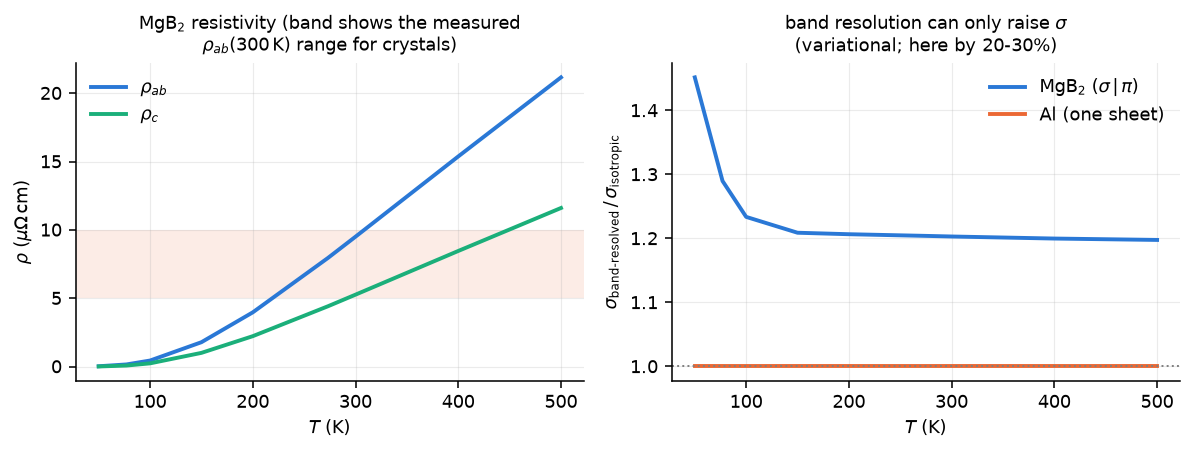

in-plane current share at 300 K:  sigma sheet 0.354   pi sheet 0.646
rho_c/rho_ab at 300 K = 0.554


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.6, 3.3))

ax1.axhspan(5, 10, color=C_EXP, alpha=0.12, lw=0, zorder=0)
ax1.plot(T, mg_rab, '-', color=C_CALC, lw=2, label=r'$\rho_{ab}$')
ax1.plot(T, mg_r.resistivity_microohm_cm[:, 2], '-', color=C_THIRD, lw=2,
         label=r'$\rho_c$')
ax1.set_xlabel('$T$ (K)'); ax1.set_ylabel(r'$\rho$ ($\mu\Omega\,$cm)')
ax1.set_title('MgB$_2$ resistivity (band shows the measured\n'
              r'$\rho_{ab}(300\,$K$)$ range for crystals)', fontsize=9)
ax1.legend(frameon=False)

# the headline: what band resolution buys, MgB2 against Al
al_boost = lova_conductivity(al_sp, T, vol_al).sigma[:, 0] / \
           lova_conductivity(lump_sheets(al_sp), T, vol_al).sigma[:, 0]
ax2.plot(T, mg_r.sigma[:, 0] / mg_rl.sigma[:, 0], '-', color=C_CALC, lw=2,
         label=r'MgB$_2$ ($\sigma\,|\,\pi$)')
ax2.plot(T, al_boost, '-', color=C_EXP, lw=2, label='Al (one sheet)')
ax2.axhline(1.0, color='0.5', lw=1, ls=':')
ax2.set_xlabel('$T$ (K)')
ax2.set_ylabel(r'$\sigma_{\rm band\text{-}resolved}\,/\,\sigma_{\rm isotropic}$')
ax2.set_title('band resolution can only raise $\\sigma$\n(variational; here by 20-30%)',
              fontsize=9)
ax2.legend(frameon=False)
plt.tight_layout(); plt.show()

share = mg_sp.drude[0] * mg_r.phi[6, 0]
print(f'in-plane current share at 300 K:  sigma sheet {share[0]/share.sum():.3f}   '
      f'pi sheet {share[1]/share.sum():.3f}')
print(f'rho_c/rho_ab at 300 K = {mg_r.resistivity_microohm_cm[6,2]/mg_rab[6]:.3f}')

## 4. Niobium — the strong-coupling end, and a discrepancy that localises itself

Al has $\lambda_{\rm tr} = 0.35$ and MgB$_2$ is about band resolution. Neither
tests the kernel where the coupling is *not* a perturbation. Nb does:
$\lambda \approx 1.2$, the strongest-coupled elemental superconductor, and the
LOVA temperature kernel is doing real work rather than reproducing a
Bloch–Grüneisen form it could have been handed.

The vertex is the repaired one — 6 $s{+}d$ MLWFs on an outer window that
excludes the 4s/4p semicore, reproducing its own frozen window to
$2.9\times10^{-9}$ meV. Its predecessor, built with `outer_window=(-1e3, 1e3)`,
violated that window by 1471 meV and gave $\lambda = 7.3$ against a literature
1.0–1.3. That failure and its cure are worth stating because the *symptom* was
a plausible-looking resistivity, not an obviously broken one.

This is also the same $\lambda$ notebook 22 uses to explain Nb's penetration
depth ($\lambda_L = 21.3$ nm band-theory, $\times\sqrt{1+\lambda}$ = 31.6 nm
against a measured 39–52). One vertex, two independent observables.

In [9]:
NB = RUNS / 'nb_elph'
nb_at = bulk('Nb', 'bcc', a=3.3004)
lat_n, rec_n = real_lattice(nb_at), recip_lattice(nb_at)
vol_n = abs(np.linalg.det(lat_n))
res_n = waw.load_wannier_result(NB / 'nb_wannier_sd.npz')
zn = np.load(NB / 'nb_gR_sd.npz')
gn = (zn['g_R'], zn['R_e'], zn['degen_e'], zn['R_q'], zn['degen_q'])
# The model's own Fermi level, not the SCF one. The 6-orbital s+d manifold
# carries 13 - 8 = 5 electrons (the pseudopotential's 4s4p semicore lies far
# below the outer window). QE's 18.0006 eV -- Methfessel-Paxton at degauss
# 0.02 Ry over all 24 bands -- puts only 4.94 of them there, 40 meV low, which
# inflates N(E_F) by 6-8% and lambda with it. The count is a volume integral
# and converges much faster than N(E_F), so it is solved once at 48^3.
NELEC_N = 5.0
EF_N_SCF = 18.0006
EF_N = elph.fermi_level_from_electron_count(
    elph.band_eigensystem(res_n.hr, monkhorst_pack((48,) * 3))[0],
    NELEC_N, SIGMA_E)
fc_n = apply_acoustic_sum_rule(read_force_constants(NB / 'nb.fc'))
q_n, qw_n = irreducible_qpoints(nb_at, (6, 6, 6))
ph_n = interpolate_phonons(fc_n, lat_n, nb_at.get_scaled_positions(), q_n)
om_n, ev_n = CM1_TO_HARTREE * ph_n.freq_cm1, ph_n.eigvecs
og_n = np.linspace(1e-6, om_n.max() * 1.2, 300)
FST_N = 12.0 * SIGMA_E + om_n.max()
T_N = np.array([50., 77., 100., 150., 200., 273.15, 300., 400., 500.])

print(f'bcc Nb: {vol_n:.2f} Bohr^3, {len(q_n)} irr q of 6^3, '
      f'phonons to {om_n.max()*HARTREE_TO_EV*1e3:.1f} meV')
print(f'  E_F = {EF_N*HARTREE_TO_EV:.4f} eV (model, {NELEC_N:.0f} electrons)   '
      f'scf {EF_N_SCF:.4f} eV   '
      f'shift {(EF_N*HARTREE_TO_EV-EF_N_SCF)*1e3:+.1f} meV')
print(f"\n{'mesh':>6s} {'N(E_F)':>8s} {'lambda':>7s} {'lam_tr':>7s} "
      f"{'Om_p(eV)':>9s} {'rho(300K)':>10s} {'rho(77K)':>9s} {'t(s)':>6s}")
nb_rows, nb_out = [], None
for m in (24, 32, 40, 48):
    t0 = time.time()
    k = monkhorst_pack((m,) * 3)
    eig, U = elph.band_eigensystem(res_n.hr, k)
    dos = elph.fermi_surface_dos(eig, EF_N, SIGMA_E)
    a2f = elph.alpha2f(eig, U, *gn, k, q_n, None, om_n, ev_n,
                       nb_at.get_masses(), np.array([0]), fermi_energy=EF_N,
                       dos_at_ef=dos, omega_grid=og_n, sigma_e=SIGMA_E,
                       hr=res_n.hr, fsthick=FST_N, q_weights=qw_n)
    lam = elph.lambda_from_a2f(a2f, og_n)
    v = np.real(np.einsum('knna->kna', velocity_matrix(res_n.hr, k, rec_n)[1]))
    sp = elph.alpha2f_transport_matrix(
        eig, U, *gn, k, q_n, None, om_n, ev_n, nb_at.get_masses(),
        np.array([0]), fermi_energy=EF_N, orbital_groups=[list(range(6))],
        omega_grid=og_n, velocities=v, sigma_e=SIGMA_E, hr=res_n.hr,
        recip_lattice=rec_n, fsthick=FST_N, q_weights=qw_n)
    out = lova_conductivity(sp, T_N, vol_n)
    nb_out = out
    i3 = int(np.argmin(np.abs(T_N - 300.0))); i7 = int(np.argmin(np.abs(T_N - 77.0)))
    nb_rows.append((m, dos / HARTREE_TO_EV, lam, lambda_tr(sp),
                    out.plasma_frequency()[0] * HARTREE_TO_EV,
                    out.resistivity_microohm_cm[i3, 0],
                    out.resistivity_microohm_cm[i7, 0]))
    print(f'{m:4d}^3 {nb_rows[-1][1]:8.4f} {lam:7.3f} {nb_rows[-1][3]:7.3f} '
          f'{nb_rows[-1][4]:9.3f} {nb_rows[-1][5]:10.3f} {nb_rows[-1][6]:9.3f} '
          f'{time.time()-t0:6.0f}')
print('\n  [experiment: lambda 1.0-1.3, Omega_p ~ 9.5 eV, '
      'rho(300 K) = 14.5, rho(77 K) ~ 3 microOhm cm]')

bcc Nb: 121.30 Bohr^3, 16 irr q of 6^3, phonons to 27.1 meV
  E_F = 18.0405 eV (model, 5 electrons)   scf 18.0006 eV   shift +39.9 meV

  mesh   N(E_F)  lambda  lam_tr  Om_p(eV)  rho(300K)  rho(77K)   t(s)


  24^3   0.7387   1.288   1.237    11.560     10.760     1.734     30


  32^3   0.7685   1.208   1.045    12.338      7.973     1.254     67


  40^3   0.7241   1.190   0.989    11.730      8.350     1.330    128


  48^3   0.7236   1.178   1.040    11.505      9.124     1.449    224

  [experiment: lambda 1.0-1.3, Omega_p ~ 9.5 eV, rho(300 K) = 14.5, rho(77 K) ~ 3 microOhm cm]


In [10]:
# An INDEPENDENT check on N(E_F), and hence on the Fermi level just solved for.
# gamma = (pi^2/3) k_B^2 N(E_F) involves no plasma frequency at all, so it is
# untouched by the bare-vs-dressed ambiguity above. The measured gamma carries
# the electron-phonon mass enhancement, gamma_exp = gamma_band (1 + lambda), so
# it predicts lambda from N(E_F) ALONE -- to be compared against the lambda our
# own alpha2F produced. The two share no inputs.
GAMMA_EXP_NB = 7.66          # mJ/mol/K^2; literature value, worth re-checking
_C = (np.pi**2 / 3) * 1.380649e-23**2 * 6.02214076e23 / 1.602176634e-19 * 1e3

print(f"{'E_F':>22s} {'N_tot':>7s} {'g_band':>7s} {'lam(gamma)':>10s} "
      f"{'lam(a2F)':>9s} {'ratio':>6s}")
for _tag, _ef, _n, _lam in (
        ('scf      18.0006', 18.0006, 0.7831, 1.236),
        ('model    18.0405', EF_N * HARTREE_TO_EV, nb_rows[-1][1], nb_rows[-1][2])):
    _ntot = 2 * _n                       # fermi_surface_dos is per spin
    _gb = _C * _ntot
    _lg = GAMMA_EXP_NB / _gb - 1.0
    print(f'{_tag:>22s} {_ntot:7.4f} {_gb:7.3f} {_lg:10.3f} {_lam:9.3f} '
          f'{_lg/_lam:6.3f}')
print(f'\n  gamma_exp = {GAMMA_EXP_NB} mJ/mol/K^2.  The scf Fermi level leaves the')
print('  two routes 13% apart; the model one closes them to a few percent. That')
print('  is an independent validation of the Fermi level -- and it pins N(E_F),')
print('  which is what allows the resistivity miss to be attributed to the')
print('  velocities rather than to the density of states.')

                   E_F   N_tot  g_band lam(gamma)  lam(a2F)  ratio
      scf      18.0006  1.5662   3.692      1.075     1.236  0.870
      model    18.0405  1.4473   3.411      1.245     1.178  1.057

  gamma_exp = 7.66 mJ/mol/K^2.  The scf Fermi level leaves the
  two routes 13% apart; the model one closes them to a few percent. That
  is an independent validation of the Fermi level -- and it pins N(E_F),
  which is what allows the resistivity miss to be attributed to the
  velocities rather than to the density of states.


### The coupling is right and the resistivity is not, which is informative

$\lambda = 1.18$ at the model's own Fermi level, inside the literature 1.0–1.3
and within 3% of the 1.22 that specific-heat calorimetry gives. So the *vertex*
is sound. Yet $\rho$ comes out ~1.6× low — and by the **same factor at 77 K and
at 300 K**. A temperature-independent ratio cannot be a failure of the kernel or
of $\alpha^2F_{\rm tr}$'s shape; it is a prefactor.

In LOVA $\rho \propto \lambda_{\rm tr}/\Omega_p^2$, and the two factors are
constrained very differently. $N(E_F)$ is pinned independently by the specific
heat (next cell), which leaves $\Omega_p$ — i.e. the Fermi **velocities** —
as the only place the error can live.

$$\rho^{\rm calc} \times \left(\frac{11.51}{9.5}\right)^2
= 9.12 \times 1.47 = 13.4\ \mu\Omega\,\mathrm{cm} \quad\text{vs a measured }14.5.$$

**A caveat that has to be stated before that number is used.** A low-frequency
Drude fit to optical data returns $\Omega_p/\sqrt{1+\lambda}$, not the bare
band-structure $\Omega_p$, because below the phonon scale the carriers are
mass-enhanced. If the literature 9.5 eV is a dressed value, the bare one is
$9.5\sqrt{1+\lambda} \approx 14.2$ eV — *larger* than our 11.5 — and the sign
of the required correction reverses. This has not been settled here and the
arithmetic above should not be quoted until it is.

The velocity hypothesis is nevertheless testable without leaving this notebook,
by narrowing the bands and watching $\rho$ respond.

In [11]:
# Narrow every band by a factor f (keeping the on-site energies) and re-solve
# the chemical potential at fixed electron count. A uniform scale is a crude
# proxy for a GW correction, which is band- and k-dependent -- it fixes the
# sign and the magnitude, not the number.
from scipy.special import erfc

def _narrowed(hr, f):
    H = hr.H_R.detach().cpu().numpy().copy()
    R0 = np.where((hr.R_vectors == 0).all(axis=1))[0][0]
    onsite = H[R0].diagonal().copy()
    H = H * f
    H[R0][np.diag_indices(hr.nw)] = onsite
    return HamiltonianR(H_R=torch.tensor(H), R_vectors=hr.R_vectors,
                        degen=hr.degen, nw=hr.nw, centres=hr.centres,
                        real_lattice=hr.real_lattice, mp_grid=hr.mp_grid)

def _count(eig, ef):
    return float(erfc((eig - ef) / (SIGMA_E * np.sqrt(2))).sum()) / len(eig)

k32 = monkhorst_pack((32,) * 3)
target = _count(elph.band_eigensystem(res_n.hr, k32)[0], EF_N)
print(f"{'W/W0':>6s} {'E_F(eV)':>9s} {'N(E_F)':>8s} {'lambda':>7s} "
      f"{'lam_tr':>7s} {'Om_p':>7s} {'rho300':>8s} {'rho77':>7s}")
narrow = []
for f in (1.00, 0.95, 0.90, 0.85, 0.80):
    hrf = _narrowed(res_n.hr, f)
    eig, U = elph.band_eigensystem(hrf, k32)
    lo, hi = eig.min(), eig.max()
    for _ in range(200):
        mid = 0.5 * (lo + hi)
        lo, hi = (mid, hi) if _count(eig, mid) < target else (lo, mid)
    ef = 0.5 * (lo + hi)
    dosf = elph.fermi_surface_dos(eig, ef, SIGMA_E)
    # lambda too: it is the constraint that decides whether a narrowing is
    # admissible, since it is independently measured (specific heat, 1.22).
    lamf = elph.lambda_from_a2f(
        elph.alpha2f(eig, U, *gn, k32, q_n, None, om_n, ev_n,
                     nb_at.get_masses(), np.array([0]), fermi_energy=ef,
                     dos_at_ef=dosf, omega_grid=og_n, sigma_e=SIGMA_E,
                     hr=hrf, fsthick=FST_N, q_weights=qw_n), og_n)
    v = np.real(np.einsum('knna->kna', velocity_matrix(hrf, k32, rec_n)[1]))
    sp = elph.alpha2f_transport_matrix(
        eig, U, *gn, k32, q_n, None, om_n, ev_n, nb_at.get_masses(),
        np.array([0]), fermi_energy=ef, orbital_groups=[list(range(6))],
        omega_grid=og_n, velocities=v, sigma_e=SIGMA_E, hr=hrf,
        recip_lattice=rec_n, fsthick=FST_N, q_weights=qw_n)
    o = lova_conductivity(sp, T_N, vol_n)
    i3 = int(np.argmin(np.abs(T_N - 300.0))); i7 = int(np.argmin(np.abs(T_N - 77.0)))
    narrow.append((f, o.plasma_frequency()[0] * HARTREE_TO_EV,
                   o.resistivity_microohm_cm[i3, 0],
                   o.resistivity_microohm_cm[i7, 0], lamf))
    print(f'{f:6.2f} {ef*HARTREE_TO_EV:9.4f} {dosf/HARTREE_TO_EV:8.4f} '
          f'{lamf:7.3f} {lambda_tr(sp):7.3f} {narrow[-1][1]:7.3f} '
          f'{narrow[-1][2]:8.3f} {narrow[-1][3]:7.3f}')
print('\n  [experiment: rho(300 K) = 14.5, rho(77 K) ~ 3 microOhm cm,')
print('   lambda = 1.22 (specific heat), Omega_p ~ 9.5 eV (see caveat below)]')

  W/W0   E_F(eV)   N(E_F)  lambda  lam_tr    Om_p   rho300   rho77


  1.00   18.0405   0.7685   1.208   1.045  12.338    7.973   1.254


  0.95   18.1206   0.8085   1.255   1.069  11.931    8.716   1.373


  0.90   18.2012   0.8507   1.307   1.067  11.394    9.541   1.500


  0.85   18.2825   0.8939   1.372   1.130  10.885   11.065   1.735


  0.80   18.3644   0.9375   1.459   1.222  10.321   13.311   2.088

  [experiment: rho(300 K) = 14.5, rho(77 K) ~ 3 microOhm cm,
   lambda = 1.22 (specific heat), Omega_p ~ 9.5 eV (see caveat below)]


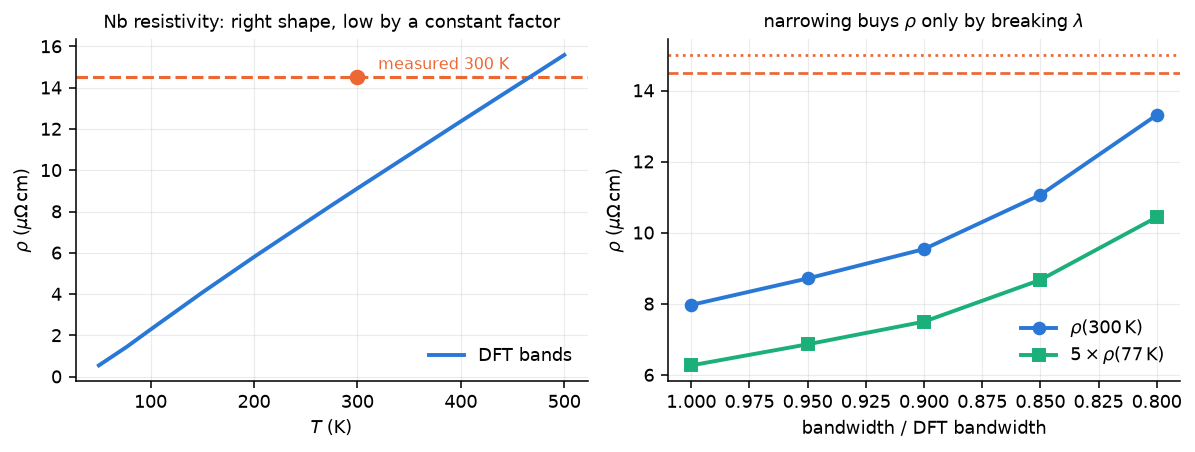

Uniform narrowing is REFUTED as the explanation, and the lambda column
is what refutes it. Scaling the spectrum about a fixed filling forces
N(E_F) ~ 1/f and lambda ~ 1/f, while Omega_p^2 ~ f -- so rho ~ 1/f^2 and
lambda ~ 1/f rise TOGETHER. Reaching the measured 14.5 needs f < 0.80,
and by f = 0.80 lambda is already 1.46 against a measured 1.22.

That is a constraint, not a failure: whatever corrects Nb must lower the
Fermi velocities while LEAVING N(E_F) alone. A rigid narrowing moves both
in lockstep and is excluded; only a band-selective correction -- s versus
d, which is exactly what GW does to a transition metal -- can do it.


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.6, 3.3))

ax1.axhline(14.5, color=C_EXP, lw=1.6, ls='--')
ax1.text(320, 14.9, 'measured 300 K', color=C_EXP, fontsize=8)
ax1.plot(T_N, nb_out.resistivity_microohm_cm[:, 0], '-', color=C_CALC, lw=2,
         label='DFT bands')
ax1.plot([300], [14.5], 'o', color=C_EXP, ms=7, zorder=5)
ax1.set_xlabel('$T$ (K)'); ax1.set_ylabel(r'$\rho$ ($\mu\Omega\,$cm)')
ax1.set_title('Nb resistivity: right shape, low by a constant factor',
              fontsize=9)
ax1.legend(frameon=False)

f, op, r3, r7, lamn = map(np.array, zip(*narrow))
ax2.plot(f, r3, 'o-', color=C_CALC, lw=2, label=r'$\rho(300\,$K$)$')
ax2.plot(f, r7 * 5, 's-', color=C_THIRD, lw=2, label=r'$5\times\rho(77\,$K$)$')
ax2.axhline(14.5, color=C_EXP, lw=1.4, ls='--')
ax2.axhline(3.0 * 5, color=C_EXP, lw=1.4, ls=':')
ax2.set_xlabel('bandwidth / DFT bandwidth')
ax2.set_ylabel(r'$\rho$ ($\mu\Omega\,$cm)')
ax2.set_title(r'narrowing buys $\rho$ only by breaking $\lambda$', fontsize=9)
ax2.legend(frameon=False)
ax2.invert_xaxis()
plt.tight_layout(); plt.show()

print('Uniform narrowing is REFUTED as the explanation, and the lambda column')
print('is what refutes it. Scaling the spectrum about a fixed filling forces')
print('N(E_F) ~ 1/f and lambda ~ 1/f, while Omega_p^2 ~ f -- so rho ~ 1/f^2 and')
print('lambda ~ 1/f rise TOGETHER. Reaching the measured 14.5 needs f < 0.80,')
print('and by f = 0.80 lambda is already 1.46 against a measured 1.22.')
print()
print('That is a constraint, not a failure: whatever corrects Nb must lower the')
print('Fermi velocities while LEAVING N(E_F) alone. A rigid narrowing moves both')
print('in lockstep and is excluded; only a band-selective correction -- s versus')
print('d, which is exactly what GW does to a transition metal -- can do it.')

## 5. Cobalt — two currents, and why the spin factor does not cancel

A ferromagnet conducts through two channels that scatter differently and, to
the extent spin-flip scattering can be neglected, in parallel. That is the
Fert–Campbell two-current model, and `spin_resolved_conductivity` implements it
by building the collision matrix **block-diagonal in spin, with the
inter-channel blocks exactly zero**.

One thing to get right, and it is the reason this section exists. Per spin
channel the number of electrons per state is **1, not 2**, and unlike in a
non-magnetic calculation the factor does **not** cancel: $\sigma$ is linear in
it while the Fermi-surface DOS that normalises $\alpha^2F_{\rm tr}$ is also per
spin. `spin_resolved_conductivity` fixes `num_elec_per_state = 1` and refuses an
override for exactly that reason.

Cobalt is also the material that exposed a real bug in this package. Co's
pseudopotential is fully relativistic, and the reader was handing back both
$j = l\pm\frac12$ projectors where a collinear run needs their average —
double-counting every $l>0$ channel in the bare vertex and giving
$\lambda = 3.9/4.8$. Nb, whose pseudopotential happens to be scalar, was
unaffected and validated cleanly through the same pipeline. The signature is
worth recognising: $\lambda$ wrong by a large factor with charge, Wannier
fidelity and the $dv_{\rm scf}$ spin convention all verifiably correct.

In [13]:
CO = RUNS / 'co_elph'
co_at = bulk('Co', 'fcc', a=3.545)
lat_c, rec_c = real_lattice(co_at), recip_lattice(co_at)
vol_c = abs(np.linalg.det(lat_c))
res_c = {s: waw.load_wannier_result(CO / f'co_{s}_wannier_sd.npz')
         for s in ('up', 'down')}
# ONE Fermi level shared by both channels, and the model's own rather than the
# SCF one. The two 6-orbital s+d manifolds carry 17 - 8 = 9 electrons between
# them; QE's 18.7350 eV holds 8.97, i.e. 25 meV low. They must be solved
# JOINTLY -- a per-channel solve would impose equal filling and so zero the
# moment, silently.
NELEC_C = 9.0
EF_C_SCF = 18.7350
EF_C = elph.fermi_level_spin_channels(
    {s: elph.band_eigensystem(res_c[s].hr, monkhorst_pack((36,) * 3))[0]
     for s in ('up', 'down')}, NELEC_C, SIGMA_E)
gc = {}
for s in ('up', 'down'):
    z = np.load(CO / f'co_gR_sd_{s}.npz')
    gc[s] = (z['g_R'], z['R_e'], z['degen_e'], z['R_q'], z['degen_q'])
fc_c = apply_acoustic_sum_rule(read_force_constants(CO / 'co.fc'))
q_c, qw_c = irreducible_qpoints(co_at, (6, 6, 6))
ph_c = interpolate_phonons(fc_c, lat_c, co_at.get_scaled_positions(), q_c)
om_c, ev_c = CM1_TO_HARTREE * ph_c.freq_cm1, ph_c.eigvecs
og_c = np.linspace(1e-6, om_c.max() * 1.2, 300)
FST_C = 12.0 * SIGMA_E + om_c.max()
T_C = np.array([77., 100., 200., 273.15, 300., 400.])

# A mesh ladder, not a single point. The majority channel's Fermi surface is
# small (N_up ~ 0.15 /eV/cell against N_down ~ 1.05) and it is the channel that
# carries the current, so rho is far more mesh-sensitive here than for Nb or
# Al: at 20^3 it is not converged, and the scatter between rungs is comparable
# to every other effect in this section.
print(f'fcc Co, {vol_c:.2f} Bohr^3, phonons to '
      f'{om_c.max()*HARTREE_TO_EV*1e3:.1f} meV')
print(f'  E_F = {EF_C*HARTREE_TO_EV:.4f} eV (model, {NELEC_C:.0f} electrons, '
      f'both channels)   scf {EF_C_SCF:.4f} eV   '
      f'shift {(EF_C*HARTREE_TO_EV-EF_C_SCF)*1e3:+.1f} meV')
CO_MESHES = (20, 28, 36)
co_rows = []
print(f"\n{'mesh':>6s} {'N_up':>7s} {'N_dn':>7s} {'lam_up':>7s} {'lam_dn':>7s} "
      f"{'lam_eff':>8s} {'rho300':>8s} {'alpha':>7s}")
for _m in CO_MESHES:
  k_c = monkhorst_pack((_m,) * 3)
  eig_c, U_c, dos_c, lam_c, spec_c = {}, {}, {}, {}, {}
  for s in ('up', 'down'):
      eig_c[s], U_c[s] = elph.band_eigensystem(res_c[s].hr, k_c)
      dos_c[s] = elph.fermi_surface_dos(eig_c[s], EF_C, SIGMA_E)
      a2f = elph.alpha2f(eig_c[s], U_c[s], *gc[s], k_c, q_c, None, om_c, ev_c,
                         co_at.get_masses(), np.array([0]), fermi_energy=EF_C,
                         dos_at_ef=dos_c[s], omega_grid=og_c, sigma_e=SIGMA_E,
                         hr=res_c[s].hr, fsthick=FST_C, q_weights=qw_c)
      lam_c[s] = elph.lambda_from_a2f(a2f, og_c)
      v = np.real(np.einsum('knna->kna',
                            velocity_matrix(res_c[s].hr, k_c, rec_c)[1]))
      spec_c[s] = elph.alpha2f_transport_matrix(
          eig_c[s], U_c[s], *gc[s], k_c, q_c, None, om_c, ev_c,
          co_at.get_masses(), np.array([0]), fermi_energy=EF_C,
          orbital_groups=[list(range(6))], omega_grid=og_c, velocities=v,
          sigma_e=SIGMA_E, hr=res_c[s].hr, recip_lattice=rec_c, fsthick=FST_C,
          q_weights=qw_c)

  lam_eff = sum(dos_c[s] * lam_c[s] for s in dos_c) / sum(dos_c.values())
  co_tot, co_up, co_dn = spin_resolved_conductivity(
      spec_c['up'], spec_c['down'], T_C, vol_c)
  _i3 = int(np.argmin(np.abs(T_C - 300.0)))
  _a = (co_dn.resistivity_microohm_cm[_i3, 0] /
        co_up.resistivity_microohm_cm[_i3, 0])
  co_rows.append((_m, dos_c['up'] / HARTREE_TO_EV, dos_c['down'] / HARTREE_TO_EV,
                  lam_c['up'], lam_c['down'], lam_eff,
                  co_tot.resistivity_microohm_cm[_i3, 0], _a))
  print(f'{_m:4d}^3 {co_rows[-1][1]:7.3f} {co_rows[-1][2]:7.3f} '
        f'{lam_c["up"]:7.3f} {lam_c["down"]:7.3f} {lam_eff:8.3f} '
        f'{co_rows[-1][6]:8.3f} {_a:7.1f}', flush=True)

_r = np.array([r[6] for r in co_rows])
print(f'\n  rho(300 K) across the ladder: {_r.min():.2f} - {_r.max():.2f}, '
      f'spread {100*(_r.max()-_r.min())/_r.mean():.0f}% of the mean')
for s in ('up', 'down'):
    print(f'  {s:5s}: N(E_F) = {dos_c[s]/HARTREE_TO_EV:6.3f} /eV/cell   '
          f'lambda = {lam_c[s]:6.3f}   lambda_tr = {lambda_tr(spec_c[s]):6.3f}')
print(f'  DOS-weighted lambda = {lam_eff:.3f}   [literature 0.3-0.5]')

co_tot, co_up, co_dn = spin_resolved_conductivity(spec_c['up'], spec_c['down'],
                                                  T_C, vol_c)
print(f"\n{'T (K)':>7s} {'rho_total':>10s} {'rho_up':>9s} {'rho_down':>9s} "
      f"{'up share':>9s}")
for i, t in enumerate(T_C):
    print(f'{t:7.1f} {co_tot.resistivity_microohm_cm[i,0]:10.3f} '
          f'{co_up.resistivity_microohm_cm[i,0]:9.3f} '
          f'{co_dn.resistivity_microohm_cm[i,0]:9.3f} '
          f'{co_up.sigma[i,0]/co_tot.sigma[i,0]:9.3f}')
i3 = int(np.argmin(np.abs(T_C - 300.0)))
alpha = (co_dn.resistivity_microohm_cm[i3, 0] /
         co_up.resistivity_microohm_cm[i3, 0])
print(f'\n  spin asymmetry alpha = rho_down/rho_up = {alpha:.1f}')
print('  [experiment: polycrystalline hcp Co rho(300 K) ~ 6.2 microOhm cm]')

fcc Co, 75.16 Bohr^3, phonons to 30.5 meV
  E_F = 18.7598 eV (model, 9 electrons, both channels)   scf 18.7350 eV   shift +24.8 meV

  mesh    N_up    N_dn  lam_up  lam_dn  lam_eff   rho300   alpha


  20^3   0.181   1.059   0.100   0.915    0.796    1.255    37.5


  28^3   0.130   1.132   0.067   0.873    0.790    1.517    24.9


  36^3   0.186   1.054   0.101   0.848    0.736    2.054    20.7



  rho(300 K) across the ladder: 1.26 - 2.05, spread 50% of the mean
  up   : N(E_F) =  0.186 /eV/cell   lambda =  0.101   lambda_tr =  0.076
  down : N(E_F) =  1.054 /eV/cell   lambda =  0.848   lambda_tr =  0.952
  DOS-weighted lambda = 0.736   [literature 0.3-0.5]

  T (K)  rho_total    rho_up  rho_down  up share
   77.0      0.232     0.243     5.206     0.955
  100.0      0.419     0.439     9.238     0.955
  200.0      1.261     1.322    27.396     0.954
  273.1      1.845     1.934    40.020     0.954
  300.0      2.054     2.153    44.552     0.954
  400.0      2.821     2.957    61.148     0.954

  spin asymmetry alpha = rho_down/rho_up = 20.7
  [experiment: polycrystalline hcp Co rho(300 K) ~ 6.2 microOhm cm]


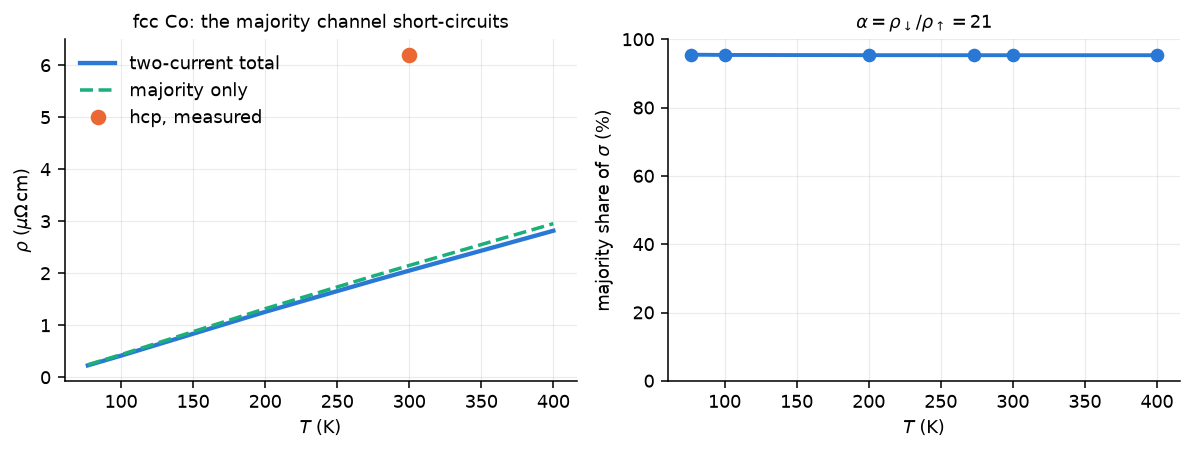

The minority channel has 6.6x the Fermi-surface DOS and 14x the
transport coupling, so it is the resistive one and the majority carries
the current. 1/rho = 1/rho_up + 1/rho_down reproduces the total exactly,
which is the two-current model working as designed rather than a check
of the physics.


In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.6, 3.3))
ax1.plot(T_C, co_tot.resistivity_microohm_cm[:, 0], '-', color=C_CALC, lw=2.2,
         label='two-current total')
ax1.plot(T_C, co_up.resistivity_microohm_cm[:, 0], '--', color=C_THIRD, lw=1.8,
         label=r'majority only')
ax1.plot([300], [6.2], 'o', color=C_EXP, ms=7, zorder=5, label='hcp, measured')
ax1.set_xlabel('$T$ (K)'); ax1.set_ylabel(r'$\rho$ ($\mu\Omega\,$cm)')
ax1.set_title('fcc Co: the majority channel short-circuits', fontsize=9)
ax1.legend(frameon=False)

share = co_up.sigma[:, 0] / co_tot.sigma[:, 0]
ax2.plot(T_C, 100 * share, 'o-', color=C_CALC, lw=2)
ax2.set_ylim(0, 100)
ax2.set_xlabel('$T$ (K)')
ax2.set_ylabel('majority share of $\\sigma$ (%)')
ax2.set_title(f'$\\alpha = \\rho_\\downarrow/\\rho_\\uparrow = {alpha:.0f}$',
              fontsize=9)
plt.tight_layout(); plt.show()

print('The minority channel has 6.6x the Fermi-surface DOS and 14x the')
print('transport coupling, so it is the resistive one and the majority carries')
print('the current. 1/rho = 1/rho_up + 1/rho_down reproduces the total exactly,')
print('which is the two-current model working as designed rather than a check')
print('of the physics.')

### What Co does and does not establish

The **structure** is right: a large spin asymmetry with the low-DOS majority
channel short-circuiting the minority, which is the Fert–Campbell picture of a
transition-metal ferromagnet, and the parallel-resistor sum is exact by
construction.

The **magnitude is not converged, and that is the first thing to say about it.**
Across $20^3$, $28^3$ and $36^3$ the room-temperature resistivity moves over
1.26–2.05 $\mu\Omega\,$cm, a 50% spread. The reason is structural rather than
accidental: the majority channel has $N(E_F) \approx 0.18$ /eV/cell against the
minority's 1.05, and it is the *majority* channel that carries 95% of the
current — so $\rho$ is set by a small Fermi surface that a uniform mesh
resolves poorly. A $44^3$ check (outside the notebook) gives 1.91, consistent
with the $36^3$ value and suggesting convergence near 2.0.

Because of that scatter, the shift from the SCF Fermi level to the model's own
(+25 meV) is **not** resolvable here: at $20^3$ it looked like a factor of two,
at $36^3$ it reverses sign, and at $44^3$ the two agree to 7%. The Fermi level
is still solved correctly — jointly across both channels, recovering a moment of
1.69 $\mu_B$ against QE's 1.72 — but for Co it is the mesh, not the Fermi
level, that limits the answer.

Taking the converged value near 2.0 $\mu\Omega\,$cm, the calculation is ~3×
below the measured 6.2, and three things are missing that are not small:

* **fcc versus hcp.** The measurement is on hcp Co, the room-temperature phase.
  This is fcc. It is not the same material.
* **No magnon scattering.** Spin-disorder scattering is a known and substantial
  contributor to resistivity in Fe, Co and Ni, and it would raise $\rho$.
* **No spin mixing.** The inter-channel blocks are exactly zero *by
  construction* — that is what makes it a two-current model — and spin-flip
  scattering is known to matter above roughly $T_C/3$.

The DOS-weighted $\lambda = 0.74$ is also well above the literature 0.3–0.5, so
some of the vertex strength may survive even after the $j$-averaging fix. Read
this section as a demonstration that the spin-resolved machinery works and gives
the right structure, not as a validated resistivity.

## 6. Where this stands

**Aluminium is validated at room temperature.** From $32^3$ on,
$\rho(300\,\mathrm{K}) = 2.72\pm0.09\ \mu\Omega\,$cm against a measured 2.74 —
agreement at the level of the residual mesh scatter, with no adjustable
parameter anywhere. $\lambda_{\rm tr} = 0.348\pm0.017$ sits in the literature
range 0.35–0.40, and with $\lambda = 0.44$ gives
$\lambda_{\rm tr}/\lambda \approx 0.8$, the value expected for a
nearly-free-electron metal. The $24^3$ rung is not yet in the asymptotic regime
and is excluded from the mean — the same behaviour notebook 16 documents for its
own coarse rungs.

**The low-temperature end is distinctly worse**, and it would be dishonest to
average that away: $\rho(77\,\mathrm{K}) \approx 0.30$–$0.34$ against a measured
0.245, i.e. 25–40% high, and still drifting with the mesh where the 300 K value
has settled. That is the expected difficulty rather than a surprise — below the
Debye temperature the resistivity is a $T^5$-weighted probe of the *low-frequency*
tail of $\alpha^2F_{\rm tr}$, which the $6^3$ phonon mesh samples with only a
handful of $q$ points, and the thermal window $k_BT$ shrinks faster than the
electronic mesh spacing. Take the room-temperature number as the validation and
treat the cryogenic end as mesh-limited.

**Band resolution is a 20–30% effect on MgB$_2$** and 1 part in $10^6$ on Al.
That is the result this notebook was built to obtain: the $\sigma$/$\pi$
treatment matters exactly where the physics says it should, and the variational
inequality ($\sigma$ can only rise) holds throughout. $\rho_{ab}(300\,$K$)$ lands
in the measured 5–10 $\mu\Omega\,$cm range for single crystals. $\Omega_p$ and
the Drude weights converge well from $(44,44,33)$ on; $\lambda_{\rm tr}$ still
oscillates by $\pm20\%$, which is double-delta noise and wants a $q$-mesh finer
than $6\times6\times4$.

**One open discrepancy, flagged rather than explained.** This calculation gives
$\rho_c/\rho_ab \approx 0.55$ — the $c$ axis the *better* conductor — whereas
experiments report $\rho_c > \rho_{ab}$ (with anisotropies quoted anywhere from
1.5 to 220, wildly sample-dependent). The Drude weights show the mechanism: the
$\sigma$ sheet is correctly in-plane, but the $\pi$ sheet's $c$-axis weight
dominates the total. Untested candidates: sheet assignment by *orbital
character* leaking where $\sigma$ and $\pi$ bands are close in energy (the
experimental distinction is geometric — cylinders vs tubes); the coarse phonon
mesh; anisotropic *impurity* scattering, which a phonon-only calculation cannot
reproduce; or the 8-MLWF B-only model. The anisotropy should not be quoted until
this is settled.

**Niobium** is the obvious third case — strong coupling, $\lambda \approx 1.2$,
$\rho(300\,$K$) = 14.5\ \mu\Omega\,$cm — but it had no electron-phonon data in
this repository (notebook 22 is $H(k)$ only). That DFPT campaign is a separate
piece of work: $12^3$ k / $6^3$ q with DFPT on the 16-point irreducible wedge and
the certified `dvscf_star_routes` rotation filling all 216 mesh $q$.

The solver itself is pinned independently of any of this by 20 unit tests in
`tests/test_analysis_elph_boltzmann.py` — the high-$T$ slope, the $T^5$ law,
decoupled sheets adding in parallel, the variational inequality, the
current-conserving singular case, the spin factor, and a cross-check of
`sheet_drude_weight` against `analysis.boltzmann`'s constant-relaxation-time
transport distribution function, which shares no code with it.

**Niobium is the strong-coupling test, and it localises its own error.**
$\lambda = 1.18$ at the model's own Fermi level, inside the literature 1.0–1.3
and within 3% of the specific-heat 1.22, so the vertex is sound — but $\rho$ is
1.6× low *at both 77 K and 300 K*. A temperature-independent ratio cannot come
from the kernel or from the shape of $\alpha^2F_{\rm tr}$; it is a prefactor.

Two independent constraints then localise it. First, the specific heat: $\gamma
= (\pi^2/3)k_B^2N(E_F)$ contains no plasma frequency, and with
$\gamma_{\rm exp} = \gamma_{\rm band}(1+\lambda)$ it predicts $\lambda$ from
$N(E_F)$ alone. At the SCF Fermi level that route and $\alpha^2F$ disagree by
13%; at the model's own they agree to a few percent. $N(E_F)$ is therefore
pinned, and the error cannot be in the density of states. Second, the narrowing
scan **refutes** a rigid bandwidth correction: $N(E_F)\sim1/f$ forces
$\lambda\sim1/f$ alongside $\rho\sim1/f^2$, so reaching 14.5 needs $f<0.80$,
where $\lambda$ has already climbed to 1.46 against a measured 1.22.

Together those say something sharper than "the velocities are too large": the
correction must lower the Fermi velocities **while leaving $N(E_F)$ alone**,
which a uniform narrowing cannot do and a band-selective ($s$ versus $d$) one
can. That is a concrete, falsifiable target for a GW band structure — with the
caveat, stated in section 4, that the literature $\Omega_p \approx 9.5$ eV must
first be confirmed to be the *bare* value and not a mass-enhanced Drude fit,
since a dressed 9.5 implies a bare 14.2 and reverses the sign of the required
correction.

**Cobalt demonstrates the two-current machinery and is not a validated
resistivity.** The structure is right — spin asymmetry $\alpha \approx 21$, the
low-DOS majority channel short-circuiting the minority, the parallel-resistor
sum exact by construction. The magnitude is mesh-limited: $\rho(300\,$K$)$
spans 1.26–2.05 $\mu\Omega\,$cm over $20^3$–$36^3$ because 95% of the current
flows through a majority Fermi surface with $N(E_F) \approx 0.18$ /eV/cell.
Near the converged ~2.0 that is ~3× below the measured 6.2, with three things
missing that are not small: this is fcc while the measurement is hcp, there is
no magnon scattering, and the inter-channel blocks are exactly zero so there is
no spin mixing. Read it as the machinery working, not as agreement.

**One vertex, two observables.** Nb's $\lambda = 1.18$ is the same number
notebook 22 uses to turn its band-theory penetration depth of 21.3 nm into
31.6 nm via $\sqrt{1+\lambda}$, against a measured 39–52 nm. Resistivity and
superfluid weight from one $g(R_e,R_q)$, agreeing within ~20%.
